In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score
)

In [2]:
try:
    relationship_df = feature_df.copy()
    print("Using feature-engineered data from memory")

except NameError:
    relationship_df = pd.read_excel(
        "clinical_feature_engineered_data.xlsx",
        sheet_name="Feature_Engineered_Data"
    )
    print("Using saved feature-engineered dataset")

print("Dataset shape:", relationship_df.shape)
relationship_df.head()

Using saved feature-engineered dataset
Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [3]:
relationship_df.columns = (
    relationship_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(relationship_df.columns.tolist())

['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [4]:
target_column = "historical_medication_class"

if target_column not in relationship_df.columns:
    raise ValueError(
        f"Target column '{target_column}' is missing."
    )

print("Number of target classes:")
print(relationship_df[target_column].nunique())

print("\nClass distribution:")
print(
    relationship_df[target_column]
    .value_counts()
)

Number of target classes:
12

Class distribution:
historical_medication_class
Antihistamine class A       52
Controller inhaler class    47
Antidiabetic class A        45
Antihypertensive class A    43
Lipid-lowering class A      42
Acid-suppression class A    42
Antidiabetic class B        42
Antihypertensive class B    42
Antihistamine class B       40
Bronchodilator class        36
Acid-suppression class B    35
Lipid-lowering class B      34
Name: count, dtype: int64


In [5]:
patient_feature_columns = [
    "age_years",
    "sex",
    "condition",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm",
    "recorded_allergy",
    "family_history",
    "adherence_level",
    "pulse_pressure_mmhg",
    "allergy_recorded_flag",
    "family_history_flag",
    "adherence_score"
]

patient_feature_columns = [
    column for column in patient_feature_columns
    if column in relationship_df.columns
]

X = relationship_df[
    patient_feature_columns
].copy()

y = relationship_df[
    target_column
].copy()

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("\nSelected features:")
print(patient_feature_columns)

Feature matrix: (500, 15)
Target: (500,)

Selected features:
['age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'pulse_pressure_mmhg', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score']


In [6]:
class_counts = y.value_counts()

class_check = pd.DataFrame({
    "medication_class": class_counts.index,
    "record_count": class_counts.values
})

class_check

,medication_class,record_count
0,Antihistamine class A,52
1,Controller inhaler class,47
2,Antidiabetic class A,45
3,Antihypertensive class A,43
4,Lipid-lowering class A,42
5,Acid-suppression class A,42
6,Antidiabetic class B,42
7,Antihypertensive class B,42
8,Antihistamine class B,40
9,Bronchodilator class,36


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print(
    "Training classes:",
    y_train.nunique()
)

print(
    "Testing classes:",
    y_test.nunique()
)

Training records: 400
Testing records: 100
Training classes: 12
Testing classes: 12


In [8]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'pulse_pressure_mmhg', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score']

Categorical features:
['sex', 'condition', 'recorded_allergy', 'family_history', 'adherence_level']


In [9]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            one_hot_encoder
        )
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [11]:
relationship_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

relationship_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
relationship_model.fit(
    X_train,
    y_train
)

print(
    "Patient–medicine relationship model trained successfully."
)

Patient–medicine relationship model trained successfully.


In [13]:
y_pred = relationship_model.predict(
    X_test
)

y_probability = relationship_model.predict_proba(
    X_test
)

print("Predictions generated:", len(y_pred))

Predictions generated: 100


In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

model_classes = relationship_model.named_steps[
    "classifier"
].classes_

top_2_accuracy = top_k_accuracy_score(
    y_test,
    y_probability,
    k=2,
    labels=model_classes
)

evaluation_results = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score",
        "Weighted F1-score",
        "Top-2 Accuracy"
    ],
    "score": [
        accuracy,
        balanced_accuracy,
        macro_f1,
        weighted_f1,
        top_2_accuracy
    ]
})

evaluation_results["score"] = (
    evaluation_results["score"].round(4)
)

evaluation_results

,metric,score
0,Accuracy,0.4600
1,Balanced Accuracy,0.4620
2,Macro F1-score,0.4564
3,Weighted F1-score,0.4576
4,Top-2 Accuracy,1.0000


In [15]:
classification_results = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

classification_results.round(4)

,precision,recall,f1-score,support
Acid-suppression class A,0.5714,0.5000,0.5333,8.00
Acid-suppression class B,0.5000,0.5714,0.5333,7.00
Antidiabetic class A,0.5000,0.4444,0.4706,9.00
Antidiabetic class B,0.4444,0.5000,0.4706,8.00
Antihistamine class A,0.4444,0.4000,0.4211,10.00
Antihistamine class B,0.3333,0.3750,0.3529,8.00
Antihypertensive class A,0.3333,0.2222,0.2667,9.00
Antihypertensive class B,0.4167,0.5556,0.4762,9.00
Bronchodilator class,0.5556,0.7143,0.6250,7.00
Controller inhaler class,0.7500,0.6000,0.6667,10.00


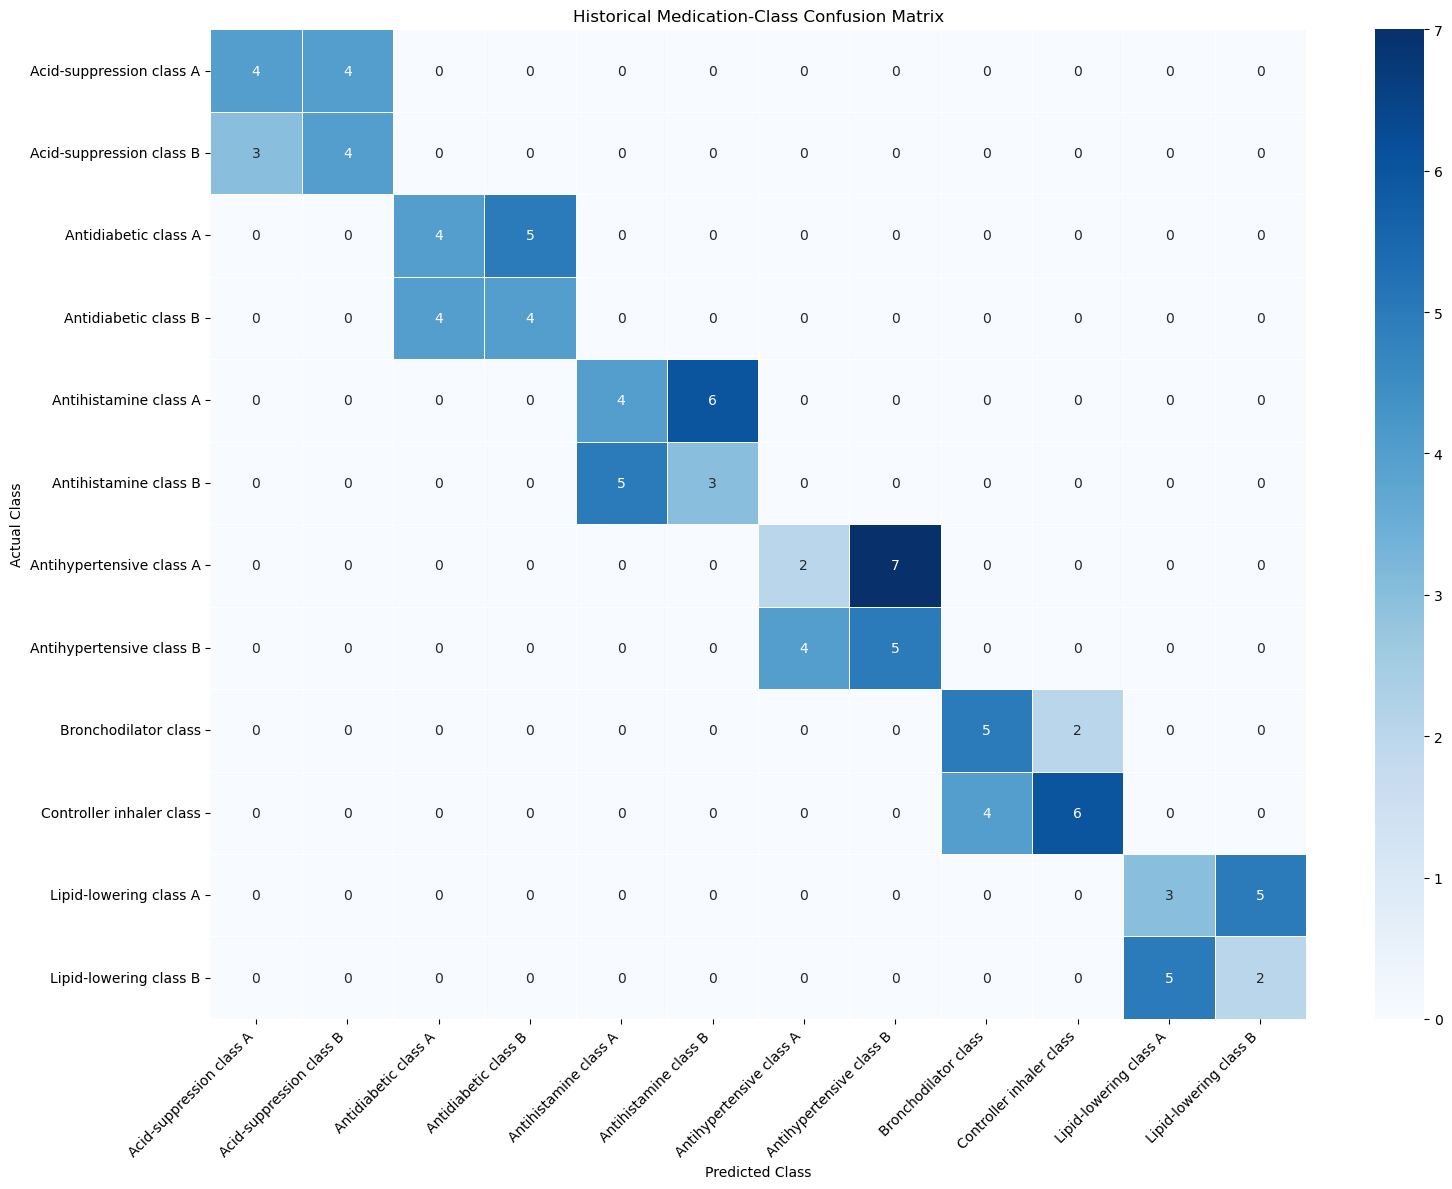

In [16]:
confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=model_classes
)

confusion_df = pd.DataFrame(
    confusion,
    index=model_classes,
    columns=model_classes
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Historical Medication-Class Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
prediction_results = X_test.copy()

prediction_results.insert(
    0,
    "patient_id",
    relationship_df.loc[
        X_test.index,
        "patient_id"
    ].values
)

prediction_results[
    "actual_medication_class"
] = y_test.values

prediction_results[
    "predicted_medication_class"
] = y_pred

prediction_results[
    "prediction_confidence"
] = y_probability.max(axis=1).round(4)

prediction_results[
    "prediction_correct"
] = (
    prediction_results[
        "actual_medication_class"
    ] ==
    prediction_results[
        "predicted_medication_class"
    ]
)

prediction_results.head(10)

,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,family_history,adherence_level,pulse_pressure_mmhg,allergy_recorded_flag,family_history_flag,adherence_score,actual_medication_class,predicted_medication_class,prediction_confidence,prediction_correct
48,SYN-0049,26,Male,Asthma,83,108,75,175,64,None recorded,No,Medium,33,0,0,1,Controller inhaler class,Controller inhaler class,0.7516,True
134,SYN-0135,27,Female,Type 2 Diabetes,187,114,67,195,81,None recorded,No,High,47,0,0,2,Antidiabetic class A,Antidiabetic class B,0.6076,False
93,SYN-0094,39,Male,High Cholesterol,108,126,88,281,78,None recorded,No,Medium,38,0,0,1,Lipid-lowering class A,Lipid-lowering class A,0.5847,True
130,SYN-0131,41,Female,High Cholesterol,114,133,65,290,84,None recorded,No,Medium,68,0,0,1,Lipid-lowering class A,Lipid-lowering class A,0.5336,True
466,SYN-0467,19,Female,Seasonal Allergy,87,132,86,222,66,None recorded,No,Low,46,0,0,0,Antihistamine class B,Antihistamine class A,0.5073,False
429,SYN-0430,74,Male,Asthma,110,114,80,213,96,None recorded,Yes,Low,34,0,1,0,Bronchodilator class,Bronchodilator class,0.6781,True
240,SYN-0241,66,Female,Hypertension,82,182,92,175,61,Sulfonamide,Yes,Medium,90,1,1,1,Antihypertensive class B,Antihypertensive class B,0.7937,True
446,SYN-0447,79,Female,Type 2 Diabetes,198,103,69,155,76,None recorded,No,Medium,34,0,0,1,Antidiabetic class B,Antidiabetic class B,0.6852,True
251,SYN-0252,74,Female,Seasonal Allergy,103,115,87,223,93,Latex,No,Low,28,1,0,0,Antihistamine class B,Antihistamine class A,0.4187,False
10,SYN-0011,41,Male,Hypertension,115,130,106,164,79,Latex,Yes,Low,24,1,1,0,Antihypertensive class A,Antihypertensive class B,0.6773,False


In [18]:
top_2_indices = np.argsort(
    y_probability,
    axis=1
)[:, -2:][:, ::-1]

prediction_results[
    "top_1_class"
] = model_classes[top_2_indices[:, 0]]

prediction_results[
    "top_1_score"
] = y_probability[
    np.arange(len(y_probability)),
    top_2_indices[:, 0]
].round(4)

prediction_results[
    "top_2_class"
] = model_classes[top_2_indices[:, 1]]

prediction_results[
    "top_2_score"
] = y_probability[
    np.arange(len(y_probability)),
    top_2_indices[:, 1]
].round(4)

prediction_results[
    [
        "patient_id",
        "actual_medication_class",
        "top_1_class",
        "top_1_score",
        "top_2_class",
        "top_2_score"
    ]
].head(10)

,patient_id,actual_medication_class,top_1_class,top_1_score,top_2_class,top_2_score
48,SYN-0049,Controller inhaler class,Controller inhaler class,0.7516,Bronchodilator class,0.2029
134,SYN-0135,Antidiabetic class A,Antidiabetic class B,0.6076,Antidiabetic class A,0.3852
93,SYN-0094,Lipid-lowering class A,Lipid-lowering class A,0.5847,Lipid-lowering class B,0.3944
130,SYN-0131,Lipid-lowering class A,Lipid-lowering class A,0.5336,Lipid-lowering class B,0.4542
466,SYN-0467,Antihistamine class B,Antihistamine class A,0.5073,Antihistamine class B,0.3383
429,SYN-0430,Bronchodilator class,Bronchodilator class,0.6781,Controller inhaler class,0.2343
240,SYN-0241,Antihypertensive class B,Antihypertensive class B,0.7937,Antihypertensive class A,0.2039
446,SYN-0447,Antidiabetic class B,Antidiabetic class B,0.6852,Antidiabetic class A,0.3095
251,SYN-0252,Antihistamine class B,Antihistamine class A,0.4187,Antihistamine class B,0.3848
10,SYN-0011,Antihypertensive class A,Antihypertensive class B,0.6773,Antihypertensive class A,0.2537


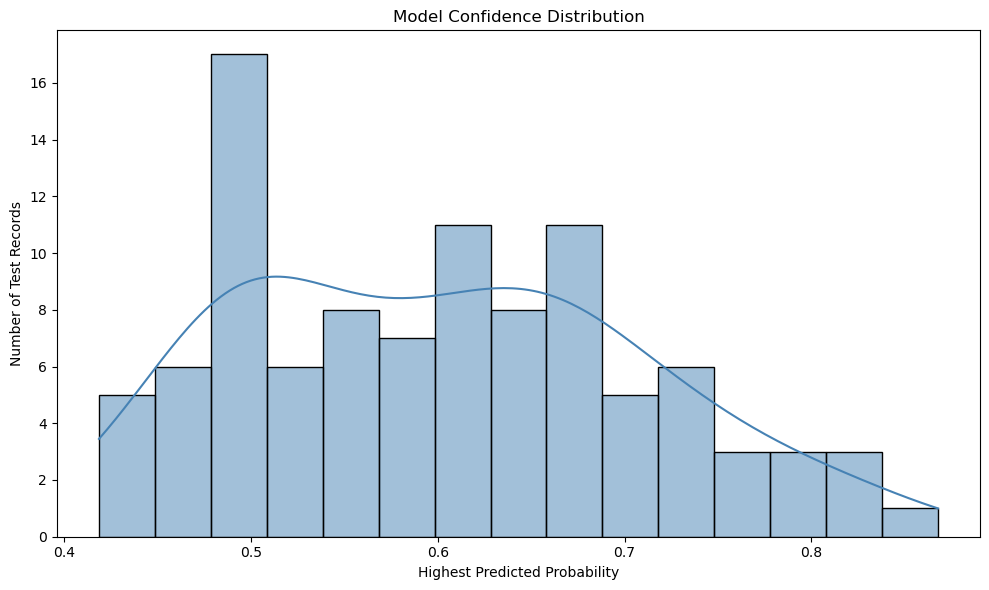

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_results[
        "prediction_confidence"
    ],
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Model Confidence Distribution")
plt.xlabel("Highest Predicted Probability")
plt.ylabel("Number of Test Records")

plt.tight_layout()
plt.show()

In [20]:
def predict_historical_medication_classes(
    patient_data,
    top_n=3
):
    input_profile = {
        column: np.nan
        for column in patient_feature_columns
    }

    input_profile.update(patient_data)

    input_df = pd.DataFrame(
        [input_profile]
    )[patient_feature_columns]

    probabilities = (
        relationship_model.predict_proba(
            input_df
        )[0]
    )

    classes = relationship_model.named_steps[
        "classifier"
    ].classes_

    top_n = min(top_n, len(classes))

    top_indices = np.argsort(
        probabilities
    )[::-1][:top_n]

    results = pd.DataFrame({
        "historical_medication_class":
            classes[top_indices],
        "model_score":
            probabilities[top_indices].round(4)
    })

    results["educational_notice"] = (
        "Synthetic historical association; "
        "not a prescription"
    )

    return results

In [21]:
sample_patient = X_test.iloc[0].to_dict()

print("Synthetic patient profile:")
display(X_test.iloc[[0]])

predict_historical_medication_classes(
    sample_patient,
    top_n=3
)

Synthetic patient profile:


,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,family_history,adherence_level,pulse_pressure_mmhg,allergy_recorded_flag,family_history_flag,adherence_score
48,26,Male,Asthma,83,108,75,175,64,None recorded,No,Medium,33,0,0,1


,historical_medication_class,model_score,educational_notice
0,Controller inhaler class,0.7516,Synthetic historical association; not a prescr...
1,Bronchodilator class,0.2029,Synthetic historical association; not a prescr...
2,Antihistamine class B,0.0107,Synthetic historical association; not a prescr...


In [22]:
output_file = "patient_medicine_relationship_results.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    evaluation_results.to_excel(
        writer,
        sheet_name="Model_Evaluation",
        index=False
    )

    classification_results.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Patient_Predictions",
        index=False
    )

    class_check.to_excel(
        writer,
        sheet_name="Class_Distribution",
        index=False
    )

print("Saved:", output_file)

Saved: patient_medicine_relationship_results.xlsx


In [23]:
joblib.dump(
    relationship_model,
    "patient_medicine_relationship_model.pkl"
)

joblib.dump(
    patient_feature_columns,
    "patient_medicine_feature_columns.pkl"
)

print("Relationship model saved successfully.")

Relationship model saved successfully.
